In [1]:
!pip install requests pandas matplotlib sqlalchemy

import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sqlalchemy import create_engine
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully")

All libraries imported successfully


In [2]:
def extract_energy_data():
    """
    Extract electricity generation data from UK National Grid ESO API.
    Returns raw JSON data for the last 7 days.
    """
    print("Extracting data from UK National Grid ESO API...")

    end_date = datetime.now()
    start_date = end_date - timedelta(days=7)

    url = "https://api.carbonintensity.org.uk/generation/{}/{}".format(
        start_date.strftime('%Y-%m-%dT%H:%MZ'),
        end_date.strftime('%Y-%m-%dT%H:%MZ')
    )

    response = requests.get(url, headers={'Accept': 'application/json'})

    if response.status_code == 200:
        data = response.json()
        print(f"Successfully fetched {len(data['data'])} records")
        return data
    else:
        print(f"API call failed with status: {response.status_code}")
        return None

raw_data = extract_energy_data()
print("Sample record:", raw_data['data'][0] if raw_data else "No data")

Extracting data from UK National Grid ESO API...
Successfully fetched 336 records
Sample record: {'from': '2026-04-26T11:30Z', 'to': '2026-04-26T12:00Z', 'generationmix': [{'fuel': 'biomass', 'perc': 7.5}, {'fuel': 'coal', 'perc': 0}, {'fuel': 'imports', 'perc': 20.6}, {'fuel': 'gas', 'perc': 5.6}, {'fuel': 'nuclear', 'perc': 16.5}, {'fuel': 'other', 'perc': 2.6}, {'fuel': 'hydro', 'perc': 0.9}, {'fuel': 'solar', 'perc': 39.1}, {'fuel': 'wind', 'perc': 7.2}]}


In [3]:
def transform_energy_data(raw_data):
    """
    Transform raw API JSON into a clean, structured DataFrame.
    - Flattens nested JSON
    - Converts timestamps to datetime
    - Calculates percentage contribution per fuel type
    - Flags renewable vs non-renewable sources
    """
    print("Transforming raw data...")

    records = []
    for entry in raw_data['data']:
        timestamp = entry['from']
        for fuel in entry['generationmix']:
            records.append({
                'timestamp': timestamp,
                'fuel_type': fuel['fuel'],
                'percentage': fuel['perc']
            })

    df = pd.DataFrame(records)

    # Convert timestamp to datetime
    df['timestamp'] = pd.to_datetime(df['timestamp'])

    # Add date and hour columns for easier analysis
    df['date'] = df['timestamp'].dt.date
    df['hour'] = df['timestamp'].dt.hour

    # Flag renewable sources
    renewables = ['wind', 'solar', 'hydro', 'biomass', 'nuclear']
    df['is_renewable'] = df['fuel_type'].isin(renewables)

    # Remove any rows with missing values
    df_clean = df.dropna()

    print(f"Transformed {len(df_clean)} records")
    print(f"Fuel types found: {df_clean['fuel_type'].unique()}")
    print(f"Date range: {df_clean['date'].min()} to {df_clean['date'].max()}")
    print(f"\nData quality check:")
    print(f"  Missing values: {df_clean.isnull().sum().sum()}")
    print(f"  Duplicate rows: {df_clean.duplicated().sum()}")

    return df_clean

df_clean = transform_energy_data(raw_data)
df_clean.head(10)

Transforming raw data...
Transformed 3024 records
Fuel types found: ['biomass' 'coal' 'imports' 'gas' 'nuclear' 'other' 'hydro' 'solar' 'wind']
Date range: 2026-04-26 to 2026-05-03

Data quality check:
  Missing values: 0
  Duplicate rows: 0


,timestamp,fuel_type,percentage,date,hour,is_renewable
0,2026-04-26 11:30:00+00:00,biomass,7.5,2026-04-26,11,True
1,2026-04-26 11:30:00+00:00,coal,0.0,2026-04-26,11,False
2,2026-04-26 11:30:00+00:00,imports,20.6,2026-04-26,11,False
3,2026-04-26 11:30:00+00:00,gas,5.6,2026-04-26,11,False
4,2026-04-26 11:30:00+00:00,nuclear,16.5,2026-04-26,11,True
5,2026-04-26 11:30:00+00:00,other,2.6,2026-04-26,11,False
6,2026-04-26 11:30:00+00:00,hydro,0.9,2026-04-26,11,True
7,2026-04-26 11:30:00+00:00,solar,39.1,2026-04-26,11,True
8,2026-04-26 11:30:00+00:00,wind,7.2,2026-04-26,11,True
9,2026-04-26 12:00:00+00:00,biomass,7.8,2026-04-26,12,True


In [4]:
def load_to_database(df, db_name='energy_data.db'):
    """
    Load clean DataFrame into SQLite database.
    Simulates a data warehouse load step.
    """
    print(f"Loading data into {db_name}...")

    engine = create_engine(f'sqlite:///{db_name}')

    # Load to database — replace table each run
    df.to_sql('energy_generation', engine,
              if_exists='replace', index=False)

    print(f"Successfully loaded {len(df)} rows into 'energy_generation' table")

    # Verify load with SQL queries
    with engine.connect() as conn:
        result = pd.read_sql("""
            SELECT
                fuel_type,
                ROUND(AVG(percentage), 2) as avg_percentage,
                COUNT(*) as record_count
            FROM energy_generation
            GROUP BY fuel_type
            ORDER BY avg_percentage DESC
        """, conn)

    print("\nDatabase verification — avg generation by fuel type:")
    print(result.to_string(index=False))
    return engine

engine = load_to_database(df_clean)
print("\nETL pipeline complete. Data ready for analysis.")

Loading data into energy_data.db...
Successfully loaded 3024 rows into 'energy_generation' table

Database verification — avg generation by fuel type:
fuel_type  avg_percentage  record_count
     wind           25.56           336
  imports           18.20           336
  nuclear           17.20           336
      gas           15.51           336
    solar           11.26           336
  biomass            7.95           336
    other            2.37           336
    hydro            1.94           336
     coal            0.00           336

ETL pipeline complete. Data ready for analysis.


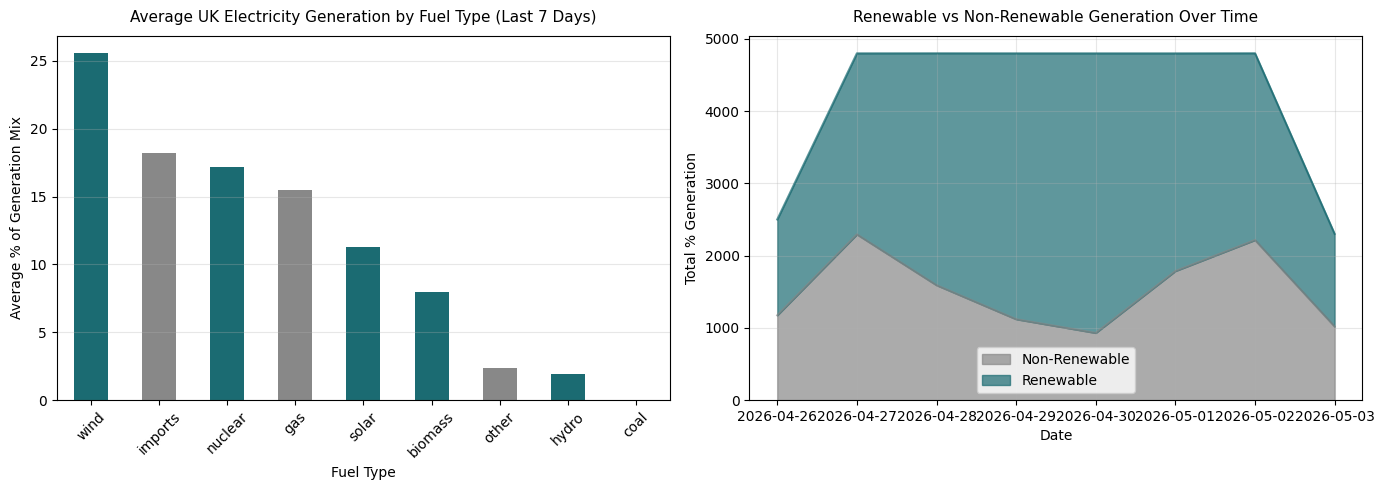

Charts saved as energy_mix_charts.png


In [5]:
with engine.connect() as conn:
    df_viz = pd.read_sql("SELECT * FROM energy_generation", conn)

# Chart 1 — Average energy mix as bar chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

avg_mix = df_viz.groupby('fuel_type')['percentage'].mean().sort_values(ascending=False)
colors = ['#1B6B72' if f in ['wind','solar','hydro','biomass','nuclear']
          else '#888' for f in avg_mix.index]
avg_mix.plot(kind='bar', ax=ax1, color=colors, edgecolor='none')
ax1.set_title('Average UK Electricity Generation by Fuel Type (Last 7 Days)',
               fontsize=11, pad=10)
ax1.set_xlabel('Fuel Type')
ax1.set_ylabel('Average % of Generation Mix')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

# Chart 2 — Renewable vs non-renewable over time
renewable_daily = df_viz.groupby(['date', 'is_renewable'])['percentage'].sum().unstack()
renewable_daily.columns = ['Non-Renewable', 'Renewable']
renewable_daily.plot(kind='area', ax=ax2, alpha=0.7,
                      color=['#888', '#1B6B72'])
ax2.set_title('Renewable vs Non-Renewable Generation Over Time',
               fontsize=11, pad=10)
ax2.set_xlabel('Date')
ax2.set_ylabel('Total % Generation')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('energy_mix_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print("Charts saved as energy_mix_charts.png")